In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    cross_val_score
)

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

## Import Library

Pada tahap klasifikasi, beberapa library digunakan untuk membantu proses pembacaan dataset, pelatihan model, evaluasi performa, serta visualisasi hasil. Library `pandas` digunakan untuk membaca dan mengelola data hasil ekstraksi fitur GLCM yang tersimpan dalam format CSV. Library `matplotlib.pyplot` digunakan untuk membuat grafik perbandingan akurasi antar algoritma dan skenario preprocessing sehingga hasil penelitian dapat dianalisis secara visual.

Dari pustaka Scikit-Learn (`sklearn`), digunakan modul `train_test_split` untuk membagi dataset menjadi data latih dan data uji, serta `cross_val_score` untuk melakukan validasi silang (Cross Validation) guna mengukur kestabilan model. Tiga algoritma klasifikasi yang digunakan dalam penelitian ini adalah `Support Vector Machine (SVM)`, `Random Forest`, dan `K-Nearest Neighbor (KNN)` yang masing-masing diimpor melalui modul `SVC`, `RandomForestClassifier`, dan `KNeighborsClassifier`.

Selain itu, digunakan beberapa metrik evaluasi yaitu `accuracy_score`, `precision_score`, `recall_score`, dan `f1_score` untuk mengukur performa klasifikasi secara lebih komprehensif. Keempat metrik tersebut digunakan untuk membandingkan kinerja setiap algoritma pada masing-masing skenario preprocessing sehingga dapat diketahui kombinasi preprocessing dan algoritma yang menghasilkan performa terbaik dalam klasifikasi citra ginjal normal dan batu ginjal.

In [3]:
DATASET = {
    "Baseline": "hasil_ekstraksi_baseline.csv",
    "P1": "hasil_ekstraksi_percobaan1.csv",
    "P2": "hasil_ekstraksi_percobaan2.csv",
    "P3": "hasil_ekstraksi_percobaan3.csv",
    "P4": "hasil_ekstraksi_percobaan4.csv"
}

## Konfigurasi Dataset

Bagian ini digunakan untuk mendefinisikan lokasi file hasil ekstraksi fitur GLCM yang akan digunakan pada tahap klasifikasi. Struktur data disimpan dalam bentuk dictionary Python dengan pasangan *key-value*, di mana *key* merepresentasikan nama skenario preprocessing, sedangkan *value* berisi nama file CSV hasil ekstraksi fitur dari skenario tersebut. Terdapat lima dataset yang digunakan, yaitu Baseline, P1, P2, P3, dan P4. Masing-masing dataset berisi fitur-fitur GLCM yang telah diekstraksi dari citra ginjal setelah melalui tahapan preprocessing yang berbeda. Pendekatan ini memudahkan proses pengujian karena seluruh dataset dapat diproses secara otomatis menggunakan perulangan tanpa perlu memanggil file satu per satu. Selain itu, penggunaan struktur dictionary membuat kode lebih ringkas, terorganisir, dan mempermudah perbandingan performa algoritma klasifikasi pada setiap skenario preprocessing yang diuji.

In [4]:
def evaluasi_model(model, X_train, X_test, y_train, y_test):

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        pos_label="kidneyStone"
    )

    recall = recall_score(
        y_test,
        y_pred,
        pos_label="kidneyStone"
    )

    f1 = f1_score(
        y_test,
        y_pred,
        pos_label="kidneyStone"
    )

    return accuracy, precision, recall, f1

## Fungsi Evaluasi Model

Fungsi `evaluasi_model()` digunakan untuk melatih model klasifikasi serta menghitung metrik evaluasi yang akan digunakan dalam penelitian. Fungsi ini menerima lima parameter, yaitu model klasifikasi yang akan diuji, data latih (`X_train` dan `y_train`), serta data uji (`X_test` dan `y_test`). Pada tahap pertama, model dilatih menggunakan data latih melalui metode `fit()`, kemudian digunakan untuk memprediksi kelas data uji menggunakan metode `predict()`. Hasil prediksi tersebut selanjutnya dibandingkan dengan label sebenarnya untuk menghitung nilai *Accuracy*, *Precision*, *Recall*, dan *F1-Score*.

Nilai *Accuracy* digunakan untuk mengukur persentase prediksi yang benar terhadap seluruh data uji. *Precision* digunakan untuk mengukur ketepatan model dalam mengidentifikasi citra batu ginjal (*kidneyStone*), sedangkan *Recall* digunakan untuk mengukur kemampuan model dalam menemukan seluruh citra batu ginjal yang ada pada dataset. *F1-Score* merupakan rata-rata harmonis antara *Precision* dan *Recall* sehingga memberikan gambaran performa model yang lebih seimbang. Parameter `pos_label="kidneyStone"` digunakan agar perhitungan metrik berfokus pada kelas batu ginjal sebagai kelas positif. Pada akhir fungsi, seluruh nilai evaluasi dikembalikan (*return*) sehingga dapat digunakan untuk membandingkan performa algoritma SVM, Random Forest, dan K-Nearest Neighbor pada setiap skenario preprocessing yang diuji.

In [5]:
hasil = []

for nama_dataset, file_csv in DATASET.items():

    data = pd.read_csv(file_csv)

    X = data.drop(
        ["Filename", "Label"],
        axis=1
    )

    y = data["Label"]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    MODELS = {
        "SVM": SVC(),
        "Random Forest": RandomForestClassifier(
            n_estimators=100,
            random_state=42
        ),
        "KNN": KNeighborsClassifier(
            n_neighbors=5
        )
    }

    for nama_model, model in MODELS.items():

        acc, prec, rec, f1 = evaluasi_model(
            model,
            X_train,
            X_test,
            y_train,
            y_test
        )

        cv_score = cross_val_score(
            model,
            X,
            y,
            cv=5
        ).mean()

        hasil.append([
            nama_dataset,
            nama_model,
            acc,
            prec,
            rec,
            f1,
            cv_score
        ])

FileNotFoundError: [Errno 2] No such file or directory: 'hasil_ekstraksi_percobaan2.csv'

## Proses Pelatihan dan Pengujian Model Klasifikasi

Pada tahap ini dilakukan proses pelatihan dan pengujian terhadap seluruh dataset hasil ekstraksi fitur GLCM yang berasal dari lima skenario preprocessing, yaitu Baseline, P1, P2, P3, dan P4. Program membaca setiap file CSV menggunakan fungsi `read_csv()`, kemudian memisahkan data menjadi fitur (*feature*) dan label kelas. Kolom `Filename` dan `Label` dihapus dari data fitur karena tidak digunakan dalam proses klasifikasi, sedangkan kolom `Label` digunakan sebagai target kelas yang berisi kategori citra ginjal normal dan batu ginjal.

Selanjutnya, dataset dibagi menjadi data latih dan data uji menggunakan fungsi `train_test_split()` dengan proporsi 80% data latih dan 20% data uji. Parameter `random_state=42` digunakan agar hasil pembagian data tetap konsisten setiap kali program dijalankan, sedangkan `stratify=y` digunakan untuk menjaga proporsi jumlah data pada masing-masing kelas agar tetap seimbang antara data latih dan data uji.

Setelah proses pembagian data selesai, dibentuk tiga model klasifikasi yang akan dibandingkan dalam penelitian, yaitu Support Vector Machine (SVM), Random Forest, dan K-Nearest Neighbor (KNN). Model Random Forest menggunakan 100 pohon keputusan (*n_estimators=100*), sedangkan model KNN menggunakan nilai tetangga terdekat sebanyak 5 (*n_neighbors=5*). Ketiga model tersebut kemudian dievaluasi secara otomatis menggunakan fungsi `evaluasi_model()` yang telah dibuat sebelumnya untuk memperoleh nilai *Accuracy*, *Precision*, *Recall*, dan *F1-Score*.

Selain evaluasi menggunakan data uji, dilakukan pula validasi silang (*5-Fold Cross Validation*) menggunakan fungsi `cross_val_score()`. Teknik ini membagi dataset menjadi lima bagian dan melakukan proses pelatihan serta pengujian secara bergantian pada setiap bagian sehingga menghasilkan nilai evaluasi yang lebih stabil dan representatif. Nilai rata-rata dari lima pengujian tersebut disimpan sebagai `CV-5Fold`.

Seluruh hasil evaluasi dari setiap kombinasi dataset preprocessing dan algoritma klasifikasi kemudian disimpan ke dalam variabel `hasil` yang nantinya akan digunakan untuk membentuk tabel perbandingan performa. Dengan pendekatan ini, proses pengujian dapat dilakukan secara otomatis terhadap seluruh skenario preprocessing dan seluruh algoritma klasifikasi sehingga memudahkan analisis pengaruh preprocessing terhadap performa klasifikasi citra ginjal normal dan batu ginjal.

## Pembuatan Tabel Hasil Evaluasi

Pada tahap ini dilakukan pembuatan tabel hasil evaluasi menggunakan struktur data `DataFrame` dari library Pandas. Seluruh hasil pengujian yang sebelumnya telah disimpan dalam variabel `hasil` dikonversi menjadi sebuah tabel dengan beberapa kolom yang merepresentasikan informasi penting dari proses klasifikasi. Kolom `Preprocessing` menunjukkan skenario preprocessing yang digunakan, kolom `Algoritma` menunjukkan metode klasifikasi yang diterapkan, sedangkan kolom `Accuracy`, `Precision`, `Recall`, dan `F1-Score` berisi nilai metrik evaluasi yang diperoleh dari proses pengujian model. Selain itu, ditambahkan kolom `CV-5Fold` yang berisi nilai rata-rata hasil *5-Fold Cross Validation* untuk mengukur kestabilan performa model pada seluruh data.

Penggunaan `DataFrame` memudahkan proses pengelolaan dan analisis data karena hasil evaluasi tersusun dalam bentuk tabel yang terstruktur dan mudah dibaca. Setelah tabel berhasil dibuat, fungsi `print(hasil_df.to_string())` digunakan untuk menampilkan seluruh isi tabel secara lengkap pada output tanpa pemotongan baris maupun kolom. Tabel inilah yang menjadi dasar dalam proses perbandingan performa algoritma SVM, Random Forest, dan K-Nearest Neighbor pada setiap skenario preprocessing sehingga dapat digunakan sebagai bahan analisis pada bagian hasil dan pembahasan penelitian.

In [ ]:
hasil_df = pd.DataFrame(
    hasil,
    columns=[
        "Preprocessing",
        "Algoritma",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "CV-5Fold"
    ]
)
print(hasil_df.to_string())

   Preprocessing      Algoritma  Accuracy  Precision  Recall  F1-Score  CV-5Fold
0       Baseline            SVM     0.900        1.0    0.80  0.888889     0.895
1       Baseline  Random Forest     1.000        1.0    1.00  1.000000     0.980
2       Baseline            KNN     1.000        1.0    1.00  1.000000     0.965
3             P1            SVM     0.975        1.0    0.95  0.974359     0.965
4             P1  Random Forest     1.000        1.0    1.00  1.000000     0.980
5             P1            KNN     1.000        1.0    1.00  1.000000     0.965
6             P2            SVM     0.950        1.0    0.90  0.947368     0.830
7             P2  Random Forest     1.000        1.0    1.00  1.000000     0.980
8             P2            KNN     0.950        1.0    0.90  0.947368     0.975
9             P3            SVM     0.950        1.0    0.90  0.947368     0.960
10            P3  Random Forest     1.000        1.0    1.00  1.000000     0.980
11            P3            

## Penyimpanan Hasil Klasifikasi

Setelah seluruh proses klasifikasi dan evaluasi selesai dilakukan, hasil pengujian disimpan ke dalam file CSV menggunakan fungsi `to_csv()`. File yang dihasilkan diberi nama `hasil_perbandingan_klasifikasi.csv` dan berisi seluruh informasi hasil evaluasi dari setiap kombinasi skenario preprocessing dan algoritma klasifikasi yang diuji. Parameter `index=False` digunakan agar nomor indeks DataFrame tidak ikut disimpan ke dalam file CSV sehingga struktur data menjadi lebih bersih dan mudah dibaca ketika dibuka menggunakan aplikasi pengolah data seperti Microsoft Excel atau Google Sheets.

Penyimpanan hasil ke dalam format CSV bertujuan untuk memudahkan proses dokumentasi, analisis lanjutan, serta pembuatan tabel pada laporan penelitian. Setelah proses penyimpanan berhasil dilakukan, program menampilkan pesan konfirmasi bahwa file telah berhasil dibuat. File inilah yang nantinya digunakan sebagai sumber data utama dalam penyusunan tabel perbandingan performa algoritma SVM, Random Forest, dan K-Nearest Neighbor pada masing-masing skenario preprocessing yang telah diuji.

In [ ]:
hasil_df.to_csv(
    "hasil_perbandingan_klasifikasi.csv",
    index=False
)

print(
    "Hasil tersimpan ke hasil_perbandingan_klasifikasi.csv"
)

Hasil tersimpan ke hasil_perbandingan_klasifikasi.csv


## Visualisasi Perbandingan Accuracy

Tahap terakhir dalam proses evaluasi adalah visualisasi hasil klasifikasi menggunakan grafik batang (*bar chart*). Data yang sebelumnya tersimpan dalam `hasil_df` terlebih dahulu diubah bentuknya menggunakan fungsi `pivot()` sehingga setiap metode preprocessing menjadi baris (*index*), setiap algoritma klasifikasi menjadi kolom (*columns*), dan nilai yang ditampilkan adalah *Accuracy*. Transformasi ini bertujuan agar data lebih mudah divisualisasikan dan dibandingkan antar algoritma pada setiap skenario preprocessing.

Selanjutnya, urutan kolom diatur secara manual menjadi SVM, Random Forest, dan KNN agar konsisten dengan urutan algoritma yang digunakan dalam penelitian. Setelah itu, grafik batang dibuat menggunakan fungsi `plot(kind="bar")` sehingga setiap metode preprocessing memiliki tiga batang yang merepresentasikan nilai akurasi dari masing-masing algoritma klasifikasi.

Label sumbu horizontal (*x-axis*) diberi nama **Preprocessing**, sedangkan sumbu vertikal (*y-axis*) diberi nama **Accuracy**. Judul grafik ditetapkan sebagai **Perbandingan Accuracy** untuk menunjukkan bahwa visualisasi ini digunakan untuk membandingkan tingkat akurasi seluruh algoritma pada setiap skenario preprocessing. Rentang sumbu Y diatur menggunakan `plt.ylim(0.85, 1.05)` agar perbedaan nilai akurasi yang relatif kecil dapat terlihat lebih jelas. Selain itu, fungsi `plt.tight_layout()` digunakan untuk mengatur tata letak grafik sehingga seluruh elemen visual dapat ditampilkan dengan rapi tanpa saling bertumpuk.

Grafik yang dihasilkan digunakan sebagai pendukung analisis hasil penelitian karena memungkinkan perbandingan performa algoritma SVM, Random Forest, dan K-Nearest Neighbor secara visual. Melalui grafik ini dapat diamati pengaruh masing-masing metode preprocessing terhadap tingkat akurasi klasifikasi citra ginjal normal dan batu ginjal.

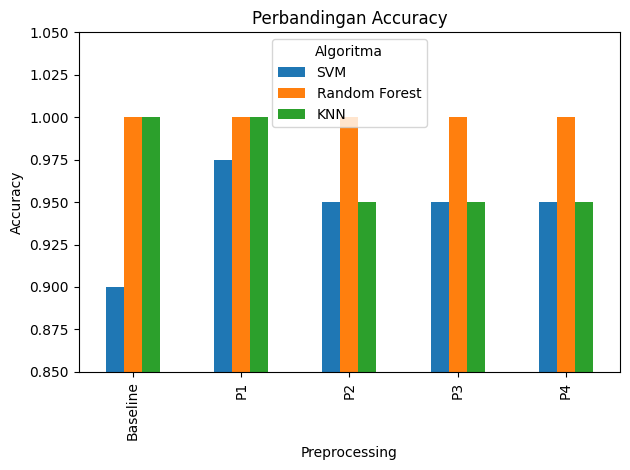

In [ ]:
pivot = hasil_df.pivot(
    index="Preprocessing",
    columns="Algoritma",
    values="Accuracy"
)

pivot = pivot[
    [
        "SVM",
        "Random Forest",
        "KNN"
    ]
]

pivot.plot(kind="bar")

plt.xlabel("Preprocessing")
plt.ylabel("Accuracy")
plt.title("Perbandingan Accuracy")

plt.ylim(0.85, 1.05)
plt.tight_layout()

plt.show()

# Analisis Hasil Klasifikasi

Berdasarkan hasil pengujian yang telah dilakukan terhadap lima skenario preprocessing, yaitu Baseline, P1, P2, P3, dan P4, terlihat bahwa metode preprocessing memberikan pengaruh yang berbeda terhadap performa masing-masing algoritma klasifikasi. Evaluasi dilakukan menggunakan metrik Accuracy, Precision, Recall, F1-Score, dan 5-Fold Cross Validation (CV-5Fold) untuk memperoleh gambaran performa model yang lebih komprehensif.

Pada algoritma Support Vector Machine (SVM), akurasi tertinggi diperoleh pada preprocessing P1 (Grayscale dan Resize) dengan nilai Accuracy sebesar 97,5%, Precision sebesar 100%, Recall sebesar 95%, dan F1-Score sebesar 97,44%. Hasil ini menunjukkan bahwa proses resize mampu meningkatkan kualitas dan konsistensi fitur tekstur yang diekstraksi menggunakan GLCM sehingga proses pemisahan kelas menjadi lebih optimal. Sebaliknya, pada dataset Baseline, SVM hanya memperoleh Accuracy sebesar 90% dengan Recall sebesar 80%, yang menunjukkan masih terdapat beberapa citra batu ginjal yang gagal diklasifikasikan dengan benar. Pada preprocessing P2, P3, dan P4, performa SVM relatif stabil dengan Accuracy sebesar 95%.

Algoritma Random Forest menunjukkan performa terbaik dibandingkan algoritma lainnya. Pada seluruh skenario preprocessing, Random Forest memperoleh Accuracy, Precision, Recall, dan F1-Score sebesar 100%. Selain itu, nilai CV-5Fold juga sangat stabil pada kisaran 98%. Hasil ini menunjukkan bahwa Random Forest mampu mempelajari pola tekstur yang dihasilkan oleh fitur GLCM secara sangat baik dan tidak terlalu sensitif terhadap variasi preprocessing yang diterapkan. Konsistensi performa ini mengindikasikan bahwa Random Forest memiliki kemampuan generalisasi yang sangat baik pada dataset yang digunakan.

Sementara itu, algoritma K-Nearest Neighbor (KNN) memperoleh performa terbaik pada Baseline dan P1 dengan Accuracy sebesar 100%. Namun, setelah diterapkan preprocessing tambahan pada P2, P3, dan P4, akurasi menurun menjadi 95%. Penurunan ini menunjukkan bahwa penerapan Median Filter, CLAHE, maupun Thresholding tidak selalu meningkatkan kualitas fitur tekstur bagi KNN. Beberapa proses preprocessing tambahan kemungkinan mengubah karakteristik tekstur asli citra sehingga memengaruhi mekanisme pencarian tetangga terdekat yang menjadi dasar kerja algoritma KNN.

Berdasarkan nilai Cross Validation, sebagian besar model menunjukkan tingkat stabilitas yang baik dengan nilai CV-5Fold berada pada rentang 96% hingga 98%. Nilai tertinggi diperoleh oleh Random Forest dan beberapa kombinasi preprocessing lainnya dengan CV-5Fold sebesar 98%. Namun demikian, SVM pada preprocessing P2 menunjukkan nilai CV-5Fold terendah sebesar 83%, yang mengindikasikan bahwa performa model tersebut kurang konsisten ketika dilakukan pengujian pada beberapa pembagian data yang berbeda.

Secara keseluruhan, hasil penelitian menunjukkan bahwa preprocessing sederhana berupa Grayscale dan Resize (P1) memberikan peningkatan performa yang signifikan pada algoritma SVM. Akan tetapi, untuk algoritma Random Forest, variasi preprocessing tidak memberikan pengaruh yang berarti karena performanya tetap mencapai 100% pada seluruh skenario. Hasil ini menunjukkan bahwa Random Forest memiliki kemampuan yang lebih robust dalam menangani variasi karakteristik fitur tekstur yang dihasilkan dari berbagai metode preprocessing.

---

# Kesimpulan

Berdasarkan hasil penelitian yang telah dilakukan, dapat disimpulkan bahwa teknik preprocessing memberikan pengaruh terhadap performa klasifikasi citra ginjal normal dan batu ginjal menggunakan fitur Gray Level Co-occurrence Matrix (GLCM). Setiap metode preprocessing menghasilkan karakteristik fitur tekstur yang berbeda sehingga memengaruhi performa algoritma klasifikasi yang digunakan.

Pada algoritma Support Vector Machine (SVM), preprocessing P1 (Grayscale dan Resize) menghasilkan performa terbaik dengan Accuracy sebesar 97,5%, Precision sebesar 100%, Recall sebesar 95%, dan F1-Score sebesar 97,44%. Hasil ini menunjukkan bahwa proses resize mampu meningkatkan kualitas fitur yang digunakan dalam proses klasifikasi.

Algoritma K-Nearest Neighbor (KNN) memperoleh performa terbaik pada Baseline dan P1 dengan Accuracy sebesar 100%, namun mengalami penurunan menjadi 95% pada preprocessing P2, P3, dan P4. Hal ini menunjukkan bahwa penambahan teknik preprocessing yang lebih kompleks tidak selalu memberikan peningkatan performa klasifikasi.

Algoritma Random Forest memberikan performa terbaik secara keseluruhan dengan Accuracy, Precision, Recall, dan F1-Score sebesar 100% pada seluruh skenario preprocessing yang diuji. Selain itu, nilai Cross Validation yang tinggi dan stabil menunjukkan bahwa Random Forest memiliki kemampuan generalisasi yang sangat baik pada dataset citra ginjal yang digunakan.

Berdasarkan seluruh hasil pengujian, Random Forest merupakan algoritma terbaik untuk klasifikasi citra ginjal normal dan batu ginjal menggunakan fitur GLCM pada penelitian ini. Sementara itu, preprocessing P1 (Grayscale dan Resize) merupakan metode preprocessing yang memberikan peningkatan performa paling signifikan, khususnya pada algoritma SVM.